# Rhabdoid cohorts clinical plots

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

/home/msanchezg/miniconda3/envs/rhabdoids/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
clinical_df = pd.read_csv('clinical_data/Clinical_Data_SJD_TARGET_StJude_PMC.tsv',sep='\t')
clinical_df

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2
0,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01
1,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02
2,pt13,0.060000,Male,MRT,Soft tissue,SJD,PT03
3,PAUDPV,0.147945,Female,MRT,Kidney,TARGET,PT04
4,SJ032417,0.170000,Female,ATRT,Brain,StJude,PT05
...,...,...,...,...,...,...,...
84,SJ030581,10.250000,Male,ATRT,Brain,StJude,PT85
85,pt5,13.500000,Male,MRT,Paraspinal,SJD,PT86
86,SJ032393,14.000000,Female,ATRT,Brain,StJude,PT87
87,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88


In [4]:
samples_final_ids_dict = json.load(open("sample_ids/sample_ids_final.json", "rb"))

## Load table with mutation data

In [5]:
smarcb1_df = pd.read_csv('variant_calling/Summary_SMARCB1_alterations.tsv',sep='\t', skiprows=1)
smarcb1_df = smarcb1_df[smarcb1_df['Excluded_samples'].isnull()]

In [6]:
smarcb1_df[['COHORT','PATIENT']].drop_duplicates().groupby(['COHORT']).count()

,PATIENT
COHORT,
PMC,1
SJD,16
St Jude,16
TARGET,56


In [7]:
clinical_df[['COHORT','PATIENT']].groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [8]:
# smarcb1_df = smarcb1_df[~smarcb1_df['SMARCB1 status'].str.contains('MYCN')]
smarcb1_df['allele1'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[0]
smarcb1_df['allele2'] = smarcb1_df['SMARCB1 status'].str.split('/',expand=True)[1]
smarcb1_df['origin_a1'] = smarcb1_df['allele1'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['origin_a2'] = smarcb1_df['allele2'].apply(lambda x: 'germline' if 'germline' in x else 'somatic')
smarcb1_df['germline'] = smarcb1_df['SMARCB1 status'].str.contains('germline')
smarcb1_df['CNLOH'] = smarcb1_df['SMARCB1 status'].str.contains('CNLOH')
smarcb1_df['COHORT'] = smarcb1_df['COHORT'].replace('St Jude','StJude')
smarcb1_df[['PATIENT','SMARCB1 status','allele1','allele2','origin_a1','origin_a2','germline']].drop_duplicates()

,PATIENT,SMARCB1 status,allele1,allele2,origin_a1,origin_a2,germline
0,pt1,del / del,del,del,somatic,somatic,False
2,pt3,R40* / exon1-del,R40*,exon1-del,somatic,somatic,False
4,pt4,del / CNLOH,del,CNLOH,somatic,somatic,False
6,pt5,del / del,del,del,somatic,somatic,False
8,pt6,S66SX / CNLOH,S66SX,CNLOH,somatic,somatic,False
...,...,...,...,...,...,...,...
106,SJ032417,del / CNLOH,del,CNLOH,somatic,somatic,False
108,SJ033236,splice variant / chrom loss,splice variant,chrom loss,somatic,somatic,False
109,SJ034089,del / del,del,del,somatic,somatic,False
110,SJ034110,I99ILDX (exon3-ins8) / del,I99ILDX (exon3-ins8),del,somatic,somatic,False


## Merge tables

In [9]:
clinical_df['PATIENT'] = clinical_df['PATIENT'].apply(lambda x: 'pt'+x if x in [str(n) for n in range(0,20)] else x)

In [10]:
merged_df = pd.merge(clinical_df,smarcb1_df,how='outer',indicator=True)

In [11]:
merged_df.groupby('_merge').count()

/tmp/ipykernel_216211/1673711432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df.groupby('_merge').count()


,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,CNLOH,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline
_merge,,,,,,,,,,,,,,,,,,,,,
left_only,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
right_only,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
both,107,107,107,107,107,107,107,107,107,107,...,107,107,17,3,0,107,107,107,107,107


In [12]:
merged_df[['PATIENT','COHORT']].drop_duplicates().groupby('COHORT').count()

,PATIENT
COHORT,
PMC,1
SJD,16
StJude,16
TARGET,56


In [13]:
merged_df[['SAMPLE','COHORT']].drop_duplicates().groupby('COHORT').count()

,SAMPLE
COHORT,
PMC,4
SJD,22
StJude,16
TARGET,56


In [14]:
merged_df['AGE_DIAGNOSIS'] = merged_df['AGE_DIAGNOSIS'].astype(float)
merged_df.sort_values('AGE_DIAGNOSIS')

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,SMARCB1 status,chr22_del_a1,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge
0,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
2,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
1,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor1,AX4933_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
3,pt18,0.010000,Female,MRT,Soft tissue,SJD,PT01,tumor2,AX4934_vs_AX4909,SMARCB1,...,I109X germline / V57X,NaN,NaN,NaN,I109X germline,V57X,germline,somatic,True,both
4,pt4,0.020000,Female,MRT,Soft tissue,SJD,PT02,tumor1,AX4916_vs_AX4896,SMARCB1,...,del / CNLOH,NaN,NaN,NaN,del,CNLOH,somatic,somatic,False,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
103,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
105,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both
104,PAUEKW,14.756164,Female,MRT,Kidney,TARGET,PT88,tumor1,PAUEKW-01A_vs_PAUEKW-10A,SMARCB1,...,exon1-5-del / del,23776542-23809445,NaN,NaN,exon1-5-del,del,somatic,somatic,False,both


In [15]:
def define_mut_type (x):
    
    if '*' in x or 'fs' in x:
        mut_type = 'frameshift'
    elif 'X' in x:
        mut_type = 'snv-nonsense'
    elif 'splice' in x:
        mut_type = 'splice variant'
    elif 'exon' in x:
        mut_type = 'exon deletion'
    elif 'del' in x:
        mut_type = 'deep deletion'
    elif 'chr22 loss' in x:
        mut_type = 'chr22 loss'
    elif 'CNLOH' in x:
        mut_type = 'CNLOH'
    elif 'amp' in x:
        mut_type = 'amplification'
    else:
        mut_type = '-'
    
    return mut_type

merged_df['mut_type_a1'] = merged_df['allele1'].apply(lambda x: define_mut_type(x))
merged_df['mut_type_a2'] = merged_df['allele2'].apply(lambda x: define_mut_type(x))
merged_df[['allele1','allele2','mut_type_a1','mut_type_a2']].groupby(['mut_type_a1','mut_type_a2']).count()

allele1  allele2
mut_type_a1    mut_type_a2                    
amplification  -                    1        1
deep deletion  -                    3        3
               CNLOH                7        7
               deep deletion       33       33
               frameshift           1        1
               snv-nonsense         2        2
exon deletion  CNLOH               13       13
               deep deletion        4        4
frameshift     -                    2        2
               CNLOH                9        9
               deep deletion        1        1
               exon deletion        2        2
               snv-nonsense         4        4
snv-nonsense   -                    3        3
               CNLOH               10       10
               deep deletion        2        2
               exon deletion        1        1
               snv-nonsense         4        4
splice variant -                    1        1
               CNLOH                3        3
               deep deletion        1        1

In [16]:
merged_df[merged_df['mut_type_a2']=='-']

,PATIENT,AGE_DIAGNOSIS,SEX,TUMOR_TYPE,PRY_TUMOR_SITE,COHORT,PATIENT2,TUMOR,SAMPLE,SYMBOL,...,chr22_del_a2,Excluded_samples,allele1,allele2,origin_a1,origin_a2,germline,_merge,mut_type_a1,mut_type_a2
34,SJ033236,0.750000,Female,ATRT,Brain,StJude,PT31,tumor1,SJBT033236_D2_vs_SJBT033236_G1,SMARCB1,...,NaN,NaN,splice variant,chrom loss,somatic,somatic,False,both,splice variant,-
51,SJ030128,1.170000,Female,ATRT,Brain,StJude,PT48,tumor1,SJBT030128_D1_vs_SJBT030128_G1,SMARCB1,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
54,PAKLYZ,1.443836,Male,MRT,Kidney,TARGET,PT51,tumor1,PAKLYZ-01A_vs_PAKLYZ-10A,MYCN,...,NaN,NaN,MYCNamp,-,somatic,somatic,False,both,amplification,-
59,SJ030707,1.580000,Male,ATRT,Brain,StJude,PT55,tumor1,SJBT030707_D2_vs_SJBT030707_G1,SMARCB1,...,NaN,NaN,A382X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
70,SJ031605,2.250000,Male,ATRT,Brain,StJude,PT65,tumor1,SJBT031605_D1_vs_SJBT031605_G1,SMARCB1,...,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
71,SJ031605,2.250000,Male,ATRT,Brain,StJude,PT65,tumor1,SJBT031605_D1_vs_SJBT031605_G1,SMARCB1,...,NaN,NaN,S258SDX and L303X,chrom loss,somatic,somatic,False,both,snv-nonsense,-
74,SJ030255,2.420000,Male,ATRT,Brain,StJude,PT68,tumor1,SJBT030255_D1_vs_SJBT030255_G1,SMARCB1,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
80,pt17,2.550000,Male,ATRT,Brain,SJD,PT71,tumor1,AX4932_vs_AX4908,SMARCB1,...,NaN,NaN,del,chrom loss,somatic,somatic,False,both,deep deletion,-
83,SJ030896,2.750000,Male,ATRT,Brain,StJude,PT74,tumor1,SJBT030896_D1_vs_SJBT030896_G1,SMARCB1,...,NaN,NaN,W206*,chrom loss,somatic,somatic,False,both,frameshift,-
93,pt11,5.570000,Female,ATRT,Brain,SJD,PT82,tumor1,AX4951_vs_AX4903,SMARCB1,...,NaN,NaN,Q123*,chrom loss,somatic,somatic,False,both,frameshift,-


## Needle plot / Mutation density plot SMARCB1

In [17]:
smarcb1_ranges_df = pd.read_csv('data/smarcb1_genomic_regions.tsv',sep='\t')
smarcb1_mane_df = smarcb1_ranges_df[smarcb1_ranges_df['Transcript stable ID']=='ENST00000644036']
cols = ['Exon stable ID','CDS start','CDS end','Exon rank in transcript']
smarcb1_exons_df = smarcb1_mane_df[cols].drop_duplicates(subset=['Exon stable ID'])
smarcb1_exons_df = smarcb1_exons_df.sort_values('Exon rank in transcript',ascending=True)
smarcb1_exons_df

,Exon stable ID,CDS start,CDS end,Exon rank in transcript
24,ENSE00003825278,1.0,93.0,1
25,ENSE00001224609,94.0,232.0,2
18,ENSE00000651413,233.0,362.0,3
19,ENSE00000879480,363.0,500.0,4
20,ENSE00003591896,501.0,628.0,5
21,ENSE00000651422,629.0,795.0,6
22,ENSE00000651425,796.0,986.0,7
23,ENSE00000651428,987.0,1118.0,8
26,ENSE00003821003,1119.0,1158.0,9


In [34]:
transcript = 'ENST00000644036'
gene_name = 'smarcb1'
ranges_df = pd.read_csv('data/'+gene_name+'_genomic_regions.tsv',sep='\t')
transcript_df = ranges_df[ranges_df['Transcript stable ID']==transcript]
cols = ['Exon stable ID','CDS start','CDS end','Exon rank in transcript']
exons_df = transcript_df[cols].drop_duplicates(subset=['Exon stable ID'])
exons_df = exons_df.sort_values('Exon rank in transcript',ascending=True)
exons_df

,Exon stable ID,CDS start,CDS end,Exon rank in transcript
24,ENSE00003825278,1.0,93.0,1
25,ENSE00001224609,94.0,232.0,2
18,ENSE00000651413,233.0,362.0,3
19,ENSE00000879480,363.0,500.0,4
20,ENSE00003591896,501.0,628.0,5
21,ENSE00000651422,629.0,795.0,6
22,ENSE00000651425,796.0,986.0,7
23,ENSE00000651428,987.0,1118.0,8
26,ENSE00003821003,1119.0,1158.0,9


In [33]:
gene_name = 'SMARCA4'.lower() 
transcript = 'ENST00000344626'

def get_exons_per_transcript(gene_name, transcript):
	# Get exons
	ranges_df = pd.read_csv('data/'+gene_name+'_genomic_regions.tsv',sep='\t')
	transcript_df = ranges_df[ranges_df['Transcript stable ID']==transcript]
	cols = ['Exon stable ID','CDS start','CDS end','Exon rank in transcript']
	exons_df = transcript_df[cols].drop_duplicates(subset=['Exon stable ID'])
	exons_df = exons_df.sort_values('Exon rank in transcript',ascending=True)
	exons_df["POS"] = exons_df.apply(lambda row: row["CDS start"] + ((row["CDS end"] - row["CDS start"]) // 2), axis=1)
	exons_df["SIZE"] = exons_df.apply(lambda row: row["CDS end"] - row["CDS start"] + 1, axis=1)
	exons_df["Color"] = "#998ec3"
 
	exons_df = exons_df[~exons_df['CDS start'].isnull()|~exons_df['CDS end'].isnull()]

	return exons_df

get_exons_per_transcript(gene_name,transcript)

,Exon stable ID,CDS start,CDS end,Exon rank in transcript,POS,SIZE,Color
384,ENSE00000874191,1.0,222.0,2,111.0,222.0,#998ec3
353,ENSE00003618181,223.0,355.0,3,289.0,133.0,#998ec3
354,ENSE00003525604,356.0,760.0,4,558.0,405.0,#998ec3
355,ENSE00003604554,761.0,859.0,5,810.0,99.0,#998ec3
356,ENSE00003531833,860.0,1118.0,6,989.0,259.0,#998ec3
357,ENSE00003670957,1119.0,1245.0,7,1182.0,127.0,#998ec3
358,ENSE00003607688,1246.0,1419.0,8,1332.0,174.0,#998ec3
359,ENSE00003546739,1420.0,1593.0,9,1506.0,174.0,#998ec3
360,ENSE00003527768,1594.0,1761.0,10,1677.0,168.0,#998ec3
361,ENSE00003667937,1762.0,1812.0,11,1787.0,51.0,#998ec3


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import collections as mc
from matplotlib import gridspec
from collections import defaultdict
from scipy.stats import norm
import matplotlib as mpl
import os
import math

### CDS coordinates
path_cds =  "data/hg38_cds.txt.gz"

PFAM_DATASETS = "data"
PFAM_file_path = os.path.join(PFAM_DATASETS, 'pfam_biomart.tsv.gz')
PFAM_info_path = os.path.join(PFAM_DATASETS, 'pfam_info.name.tsv')
df_pfam = pd.read_csv(PFAM_file_path, sep="\t", names=["ENSEMBL_GENE", "TRANSCRIPT_ID", "START", "END", "DOMAIN"])
df_names = pd.read_csv(PFAM_info_path, sep="\t", names=["DOMAIN", "CLAN", "CLAN_NAME", "DOMAIN_NAME", "Long Name"])

## Functions

def get_PFAMs_per_transcript(df_pfam, df_names, transcript):
    # Get domains
    df_pfam_gene = df_pfam[(df_pfam["TRANSCRIPT_ID"] == transcript)]
    df_pfam_gene = df_pfam_gene[["TRANSCRIPT_ID", "START", "END", "DOMAIN"]].drop_duplicates()
    df_pfam_gene = pd.merge(df_pfam_gene, df_names[["DOMAIN", "DOMAIN_NAME"]].drop_duplicates(), how="left")
    df_pfam_gene["POS"] = df_pfam_gene.apply(lambda row: row["START"] + ((row["END"] - row["START"]) // 2), axis=1)
    df_pfam_gene["SIZE"] = df_pfam_gene.apply(lambda row: row["END"] - row["START"] + 1, axis=1)
    df_pfam_gene["Color"] = "#998ec3"

    return df_pfam_gene

def get_exons_per_transcript(gene_name, transcript):
    # Get exons
    ranges_df = pd.read_csv('data/'+gene_name+'_genomic_regions.tsv',sep='\t')
    transcript_df = ranges_df[ranges_df['Transcript stable ID']==transcript]
    cols = ['Exon stable ID','CDS start','CDS end','Exon rank in transcript','Exon region start (bp)','Exon region end (bp)']
    exons_df = transcript_df[cols].drop_duplicates(subset=['Exon stable ID'])
    exons_df = exons_df.sort_values('Exon rank in transcript',ascending=True)
    exons_df = exons_df[~exons_df['CDS start'].isnull()|~exons_df['CDS end'].isnull()]
    exons = exons_df['Exon rank in transcript'].tolist()
    aa_positions_dict = {}
    end_pos = 0
    for exon in exons:
        # print(exon)
        cds_start = exons_df['CDS start'][exons_df['Exon rank in transcript']==exon]
        # print(cds_start)
        cds_end = exons_df['CDS end'][exons_df['Exon rank in transcript']==exon]
        # print(cds_end)
        
        next_start_pos = math.ceil(cds_start/3)
        next_end_pos = math.ceil(cds_end/3)
        
        size = next_end_pos - next_start_pos +1
        start_pos = end_pos
        end_pos = start_pos + size
        aa_positions_dict[exon] = {}
        aa_positions_dict[exon]['START'] = start_pos
        aa_positions_dict[exon]['END'] = end_pos
        aa_positions_dict[exon]['SIZE'] = size
        aa_positions_dict[exon]['POS'] = start_pos + ((end_pos - start_pos) // 2)
    
    exons_df['START'] = exons_df['Exon rank in transcript'].apply(lambda x: aa_positions_dict[x]['START'])
    exons_df['END'] = exons_df['Exon rank in transcript'].apply(lambda x: aa_positions_dict[x]['END'])
    exons_df['SIZE'] = exons_df['Exon rank in transcript'].apply(lambda x: aa_positions_dict[x]['SIZE'])
    exons_df['POS'] = exons_df['Exon rank in transcript'].apply(lambda x: aa_positions_dict[x]['POS'])
    
    print(aa_positions_dict)    
    
    exons_df["Color"] = "#d0cfd3"
    return exons_df


def plot_gene_full_nucleotide(subset_data_pfam, exons_df, df, gene, transcript, ax1, ax2, ax3, color_dict,ylim_max):

    # plot for each axes
    df = df[df['Protein_position'] != '-']
    df = df[df['gene'] == gene]

    # remove those mutations not falling in CDS:
    ax1.set_title(gene+ ' observed mutations',size=22)
    ax1.set_ylabel("mutation count",size=16)

    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_linewidth(1)
    ax1.spines['right'].set_visible(False)
    ax1.spines['top'].set_visible(False)
    ax1.tick_params(axis='y', labelsize=12, pad=0.25, width=0.25, length=1.5)
    ax2.tick_params(axis='x', length=0)
    ax2.set_yticks([])

    # get the max_aa
    cds_df = pd.read_csv(path_cds, sep='\t')
    cds_gene = cds_df[cds_df['Transcript stable ID'] == transcript]
    # cds_gene['CDS Length'] = cds_gene['CDS Length'].astype(int)
    if len(cds_gene) == 0:
        print('Transcript not found')
    
    max_aa = int(cds_gene['CDS Length']/3)
    
    print(max_aa)
    ax1.set_xlim(0, max_aa)
    ax1.set_ylim(0, ylim_max)

    # plot observed mutations
    
    # Define the dictionary to store proxy artists for the legend
    legend_elements = []
    
    for cons_type in df['Variant_type'].unique():
        df1 = df[df['Variant_type']==cons_type]
        color = color_dict[cons_type]
        
        pos_list = df1["Protein_position"].tolist()
        ys = df1["number_observed_muts"].values

        coordinates_mutations = []
        x_axis = []
        y_axis = []

        # for each of the positions
        for i, p in enumerate(pos_list):
            if ys[i] > 0:
                coordinates_mutations.append([(int(p), 0),
                                        (int(p), ys[i])])

                x_axis.append(int(p))
                y_axis.append(ys[i])

        lc = mc.LineCollection(coordinates_mutations, colors='black', linewidths=2, alpha=0.3)
        ax1.add_collection(lc)

        size = 50
        scatter = ax1.scatter(x_axis, y_axis, s=size, c=color, alpha=0.7)
        
        # Add a proxy artist for this scatter plot to the legend_elements list
        legend_elements.append(scatter)
    
    # Add the legend outside the loop
    ax1.legend(legend_elements, df['Variant_type'].unique(), title="Variant Type",
               bbox_to_anchor=(1, 1), loc='upper left',frameon=False,fontsize=14,title_fontsize=16) 

    ax2.set_ylim(0, 1)


    for i, r in subset_data_pfam.iterrows():
        start_base = r['START']
        size_base = r['SIZE']
        rect = patches.Rectangle(xy=(start_base, 0), width=size_base, height=5, color=r["Color"], alpha=0.5, zorder=2)
        ax2.annotate(text=r["DOMAIN_NAME"], xy=(start_base + 1, 0.3), fontsize=12)
        ax2.add_patch(rect)
        # ax2.set_xticks(np.append(np.arange(0, max_aa, 100)[:-1], max_aa))
        # ax2.set_xticklabels(np.append(np.arange(0, max_aa, 100)[:-1], max_aa), fontsize = 12)
        # ax2.set_xlim(0, max_aa)
        ax2.set_yticks([])
        ax2.set_xticks([])
        ax2.tick_params(axis='x', which='major', pad=0)
    
    if len(exons_df)>10:
        xticks_range = 500
        fontsize = 7
    else:
        xticks_range = 100
        fontsize = 9
        
    for i, r in exons_df.iterrows():
        start_base = r['START']
        size_base = r['SIZE']
        rect = patches.Rectangle(xy=(start_base, 0), width=size_base, height=5, color=r["Color"], alpha=0.5, zorder=2,edgecolor="red",linewidth=2,fill=True,linestyle='solid')
        ax3.annotate(text='E'+str(r["Exon rank in transcript"]), xy=(start_base + 1, 0.3), fontsize=fontsize)
        ax3.add_patch(rect)
        ax3.set_xticks(np.append(np.arange(0, max_aa, xticks_range)[:-1], max_aa))
        ax3.set_xticklabels(np.append(np.arange(0, max_aa, xticks_range)[:-1], max_aa), fontsize = 12)
        ax3.set_xlim(0, max_aa)
        ax3.set_yticks([])
        ax3.tick_params(axis='x', which='major', pad=3)

    ax1.tick_params(axis='x', labelsize=0, color='w')
    ax2.tick_params(axis='x', labelsize=0, color='w')

    ax3.set_xlabel('CDS base position',size=16)

    # plt.show()

In [21]:
gene_name = 'smarcb1'
transcript = 'ENST00000644036'
exons_df = get_exons_per_transcript(gene_name, transcript)
exons_df

{1: {'START': 0, 'END': 31, 'SIZE': 31, 'POS': 15}, 2: {'START': 31, 'END': 78, 'SIZE': 47, 'POS': 54}, 3: {'START': 78, 'END': 122, 'SIZE': 44, 'POS': 100}, 4: {'START': 122, 'END': 169, 'SIZE': 47, 'POS': 145}, 5: {'START': 169, 'END': 213, 'SIZE': 44, 'POS': 191}, 6: {'START': 213, 'END': 269, 'SIZE': 56, 'POS': 241}, 7: {'START': 269, 'END': 333, 'SIZE': 64, 'POS': 301}, 8: {'START': 333, 'END': 378, 'SIZE': 45, 'POS': 355}, 9: {'START': 378, 'END': 392, 'SIZE': 14, 'POS': 385}}


/tmp/ipykernel_216211/3673731263.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_start_pos = math.ceil(cds_start/3)
/tmp/ipykernel_216211/3673731263.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_end_pos = math.ceil(cds_end/3)


,Exon stable ID,CDS start,CDS end,Exon rank in transcript,Exon region start (bp),Exon region end (bp),START,END,SIZE,POS,Color
24,ENSE00003825278,1.0,93.0,1,23786966,23787262,0,31,31,15,#d0cfd3
25,ENSE00001224609,94.0,232.0,2,23791756,23791894,31,78,47,54,#d0cfd3
18,ENSE00000651413,233.0,362.0,3,23793559,23793688,78,122,44,100,#d0cfd3
19,ENSE00000879480,363.0,500.0,4,23800944,23801081,122,169,47,145,#d0cfd3
20,ENSE00003591896,501.0,628.0,5,23803295,23803422,169,213,44,191,#d0cfd3
21,ENSE00000651422,629.0,795.0,6,23816770,23816936,213,269,56,241,#d0cfd3
22,ENSE00000651425,796.0,986.0,7,23825225,23825415,269,333,64,301,#d0cfd3
23,ENSE00000651428,987.0,1118.0,8,23833572,23833703,333,378,45,355,#d0cfd3
26,ENSE00003821003,1119.0,1158.0,9,23834141,23838009,378,392,14,385,#d0cfd3


In [22]:
def needle_plot(data, gene, transcript,color_dict,ylim_max):

    # mpl.rcParams.update(mpl.rcParamsDefault)
    # plt.rcParams['font.sans-serif'] = ['DeJavu Serif']
    # plt.rcParams['font.size'] = 14
    # plt.rcParams['font.family'] = ['sans-serif']
    # plt.rcParams['svg.fonttype'] = 'none'
    # plt.rcParams['mathtext.fontset'] = 'custom'
    # plt.rcParams['mathtext.cal'] = 'arial'
    # plt.rcParams['mathtext.rm'] = 'arial'
    # mpl.rcParams['figure.dpi']= 100

    # get PFAM domains and subset the mutation data
    subset_data_pfam = get_PFAMs_per_transcript(df_pfam, df_names, transcript)
    
    # get exons positions
    gene_name = gene.lower()
    exons_df = get_exons_per_transcript(gene_name, transcript)
    

    # define figure layout
    fig = plt.figure(figsize=(15,4),dpi=200)
    # ! SDM change
    gs = gridspec.GridSpec(11, 3, figure=fig)
    ax1 = plt.subplot(gs[1:9, :2])
    ax2 = plt.subplot(gs[9:10, :2], sharex=ax1)
    ax3 = plt.subplot(gs[10:11, :2])

    # plot for each axes
    plot_gene_full_nucleotide(subset_data_pfam, exons_df, data, gene, transcript, ax1, ax2, ax3, color_dict, ylim_max)
    # ax3.set_xlabel('CDS base position')
    # plt.show()

## SMARCB1

In [23]:
import re

In [24]:
merged_df.columns

Index(['PATIENT', 'AGE_DIAGNOSIS', 'SEX', 'TUMOR_TYPE', 'PRY_TUMOR_SITE',
       'COHORT', 'PATIENT2', 'TUMOR', 'SAMPLE', 'SYMBOL', 'variant_type',
       'Consequence', 'aa_change', 'mut', 'Damaging', 'origin', 'VAF', 'CNA',
       'CN', 'Germline CNA', 'mut_sv', 'fusion', 'chr/chr', 'germ_som',
       'CNLOH', 'SMARCB1 status', 'chr22_del_a1', 'chr22_del_a2',
       'Excluded_samples', 'allele1', 'allele2', 'origin_a1', 'origin_a2',
       'germline', '_merge', 'mut_type_a1', 'mut_type_a2'],
      dtype='object')

In [25]:
cols =  ['PATIENT', 'Consequence', 'aa_change', 'mut','origin', 'VAF', 'allele1', 'allele2', ]
merged_df[cols][(merged_df['aa_change']=='-')]

,PATIENT,Consequence,aa_change,mut,origin,VAF,allele1,allele2
7,PAUDPV,"splice_acceptor_variant,coding_sequence_varian...",-,chr22:23793536:CCAGTGATGTTTGTCTGTTACAGATCACGGA...,germline,NaN,splice variant germline,CNLOH
10,PASWZZ,"splice_acceptor_variant,coding_sequence_variant",-,chr22:23816769:GAGAAGTTGAT>-,germline,NaN,splice variant germline,CNLOH
19,PAVYDM,splice_donor_variant,-,chr22:23803423:G>T,somatic,0.444,splice variant,del
34,SJ033236,splice_donor_variant,-,chr22:23803423:G>A,somatic,0.810,splice variant,chrom loss
39,PAREWI,splice_donor_variant,-,chr22:23787263:G>T,somatic,NaN,splice variant,CNLOH


In [26]:
snv_indels_df = merged_df[['PATIENT','SYMBOL','mut','aa_change','Consequence','variant_type','SMARCB1 status','allele1','allele2']][(~merged_df['mut'].isnull())&(merged_df['SYMBOL']!='SMARCA4')].drop_duplicates()
print(len(snv_indels_df))
snv_indels_df['Protein_position'] = snv_indels_df['aa_change'].apply(lambda x: re.findall(r'\d+',x))
snv_indels_df['Protein_position'] = snv_indels_df['Protein_position'].apply(lambda x: x[0] if x != [] else '-')
grp_snv_indels_df = snv_indels_df[['SYMBOL','Protein_position','Consequence','allele1','mut']].groupby(['SYMBOL','Protein_position','Consequence','mut'],as_index=False).count()

def variant_type (x):
    if ',' in x:
        x = x.split(',')[0]
    if 'splice' in x:
        y = 'Splice variant'
    elif 'frameshift' in x:
        y = 'Frameshift'
    elif x == 'stop_gained':
        y = 'SNV - Nonsense'
    else:
        y = 'other'
    return y

grp_snv_indels_df['Variant_type'] = grp_snv_indels_df['Consequence'].apply(lambda x: variant_type(x))
grp_snv_indels_df = grp_snv_indels_df.rename(columns={'allele1':'number_observed_muts','SYMBOL':'gene'})
grp_snv_indels_df['genomic_pos'] = grp_snv_indels_df['mut'].str.split(':',expand=True)[1]

def annot_prot_pos (row):
    prot_pos = row['Protein_position']
    if prot_pos == '-':
        gen_pos = row['genomic_pos']
        for exon in exons_df['Exon rank in transcript']:
            exon_gen_pos_start = exons_df['Exon region start (bp)'][exons_df['Exon rank in transcript']==exon].iloc[0]
            if int(gen_pos) < int(exon_gen_pos_start):
                prot_pos = int((exons_df['CDS start'][exons_df['Exon rank in transcript']==exon].iloc[0]) /3)
                break
    return prot_pos

grp_snv_indels_df['Protein_position'] = grp_snv_indels_df.apply(lambda row: annot_prot_pos(row),axis=1)
grp_snv_indels_df

38


,gene,Protein_position,Consequence,mut,number_observed_muts,Variant_type,genomic_pos
0,SMARCB1,77,"splice_acceptor_variant,coding_sequence_varian...",chr22:23793536:CCAGTGATGTTTGTCTGTTACAGATCACGGA...,1,Splice variant,23793536
1,SMARCB1,209,"splice_acceptor_variant,coding_sequence_variant",chr22:23816769:GAGAAGTTGAT>-,1,Splice variant,23816769
2,SMARCB1,31,splice_donor_variant,chr22:23787263:G>T,1,Splice variant,23787263
3,SMARCB1,209,splice_donor_variant,chr22:23803423:G>A,1,Splice variant,23803423
4,SMARCB1,209,splice_donor_variant,chr22:23803423:G>T,1,Splice variant,23803423
5,SMARCB1,10,frameshift_variant,chr22:23787196:TTCGGGCAGAAGCCCGTGAA>-,1,Frameshift,23787196
6,SMARCB1,10,frameshift_variant,chr22:23787197:TT>-,1,Frameshift,23787197
7,SMARCB1,109,frameshift_variant,chr22:23793678->G,1,Frameshift,23793678->G
8,SMARCB1,123,stop_gained,chr22:23800948:C>T,1,SNV - Nonsense,23800948
9,SMARCB1,164,frameshift_variant,chr22:23801073:C>-,1,Frameshift,23801073


In [27]:
# list(data['Variant_type'].unique())

color_dict = {}
color_dict['Splice variant']='orange'
color_dict['Frameshift'] = 'green'
color_dict['SNV - Nonsense'] = 'red'

/tmp/ipykernel_216211/3673731263.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_start_pos = math.ceil(cds_start/3)
/tmp/ipykernel_216211/3673731263.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_end_pos = math.ceil(cds_end/3)


{1: {'START': 0, 'END': 31, 'SIZE': 31, 'POS': 15}, 2: {'START': 31, 'END': 78, 'SIZE': 47, 'POS': 54}, 3: {'START': 78, 'END': 122, 'SIZE': 44, 'POS': 100}, 4: {'START': 122, 'END': 169, 'SIZE': 47, 'POS': 145}, 5: {'START': 169, 'END': 213, 'SIZE': 44, 'POS': 191}, 6: {'START': 213, 'END': 269, 'SIZE': 56, 'POS': 241}, 7: {'START': 269, 'END': 333, 'SIZE': 64, 'POS': 301}, 8: {'START': 333, 'END': 378, 'SIZE': 45, 'POS': 355}, 9: {'START': 378, 'END': 392, 'SIZE': 14, 'POS': 385}}


/tmp/ipykernel_216211/3673731263.py:101: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  max_aa = int(cds_gene['CDS Length']/3)
/tmp/ipykernel_216211/3673731263.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(xy=(start_base, 0), width=size_base, height=5, color=r["Color"], alpha=0.5, zorder=2,edgecolor="red",linewidth=2,fill=True,linestyle='solid')


386


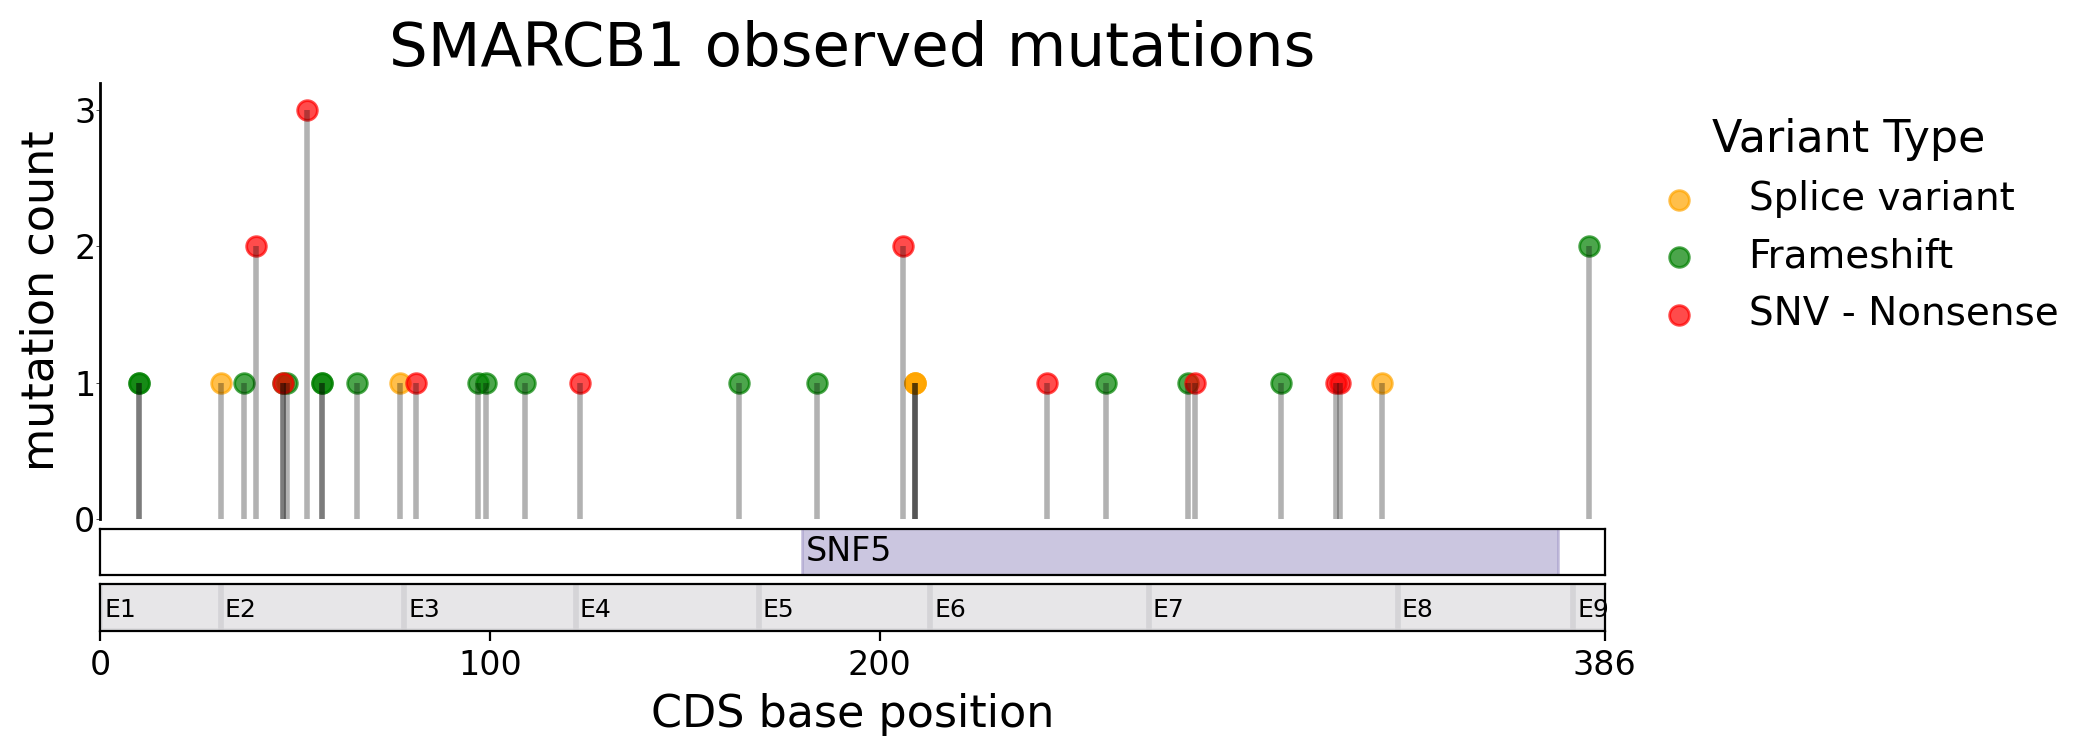

In [28]:
data = grp_snv_indels_df[['gene','Protein_position','number_observed_muts','Variant_type']].copy()

needle_plot(data, 'SMARCB1', 'ENST00000644036',color_dict,ylim_max=3.2)
plt.savefig('plots/needle_plot_smarcb1.svg', bbox_inches='tight',format='svg')
plt.show()

## SMARCA4

In [29]:
snv_indels_df = merged_df[['PATIENT','SYMBOL','mut','aa_change','Consequence','variant_type','SMARCB1 status','allele1','allele2']][(~merged_df['mut'].isnull())&(merged_df['SYMBOL']!='SMARCB1')].drop_duplicates()
print(len(snv_indels_df))
snv_indels_df['Protein_position'] = snv_indels_df['aa_change'].apply(lambda x: re.findall(r'\d+',x))
snv_indels_df['Protein_position'] = snv_indels_df['Protein_position'].apply(lambda x: x[0] if x != [] else '-')
grp_snv_indels_df = snv_indels_df[['SYMBOL','Protein_position','Consequence','mut']].groupby(['SYMBOL','Protein_position','Consequence'],as_index=False).count()

def variant_type (x):
    if ',' in x:
        x = x.split(',')[0]
    if 'splice' in x:
        y = 'Splice variant'
    elif 'frameshift' in x:
        y = 'Frameshift'
    elif x == 'stop_gained':
        y = 'SNV - Nonsense'
    else:
        y = 'other'
    return y

grp_snv_indels_df['Variant_type'] = grp_snv_indels_df['Consequence'].apply(lambda x: variant_type(x))
grp_snv_indels_df = grp_snv_indels_df.rename(columns={'mut':'number_observed_muts','SYMBOL':'gene'})
grp_snv_indels_df

2


,gene,Protein_position,Consequence,number_observed_muts,Variant_type
0,SMARCA4,1093,stop_gained,1,SNV - Nonsense
1,SMARCA4,248,frameshift_variant,1,Frameshift


/tmp/ipykernel_216211/3673731263.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_start_pos = math.ceil(cds_start/3)
/tmp/ipykernel_216211/3673731263.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_end_pos = math.ceil(cds_end/3)


{2: {'START': 0, 'END': 74, 'SIZE': 74, 'POS': 37}, 3: {'START': 74, 'END': 119, 'SIZE': 45, 'POS': 96}, 4: {'START': 119, 'END': 255, 'SIZE': 136, 'POS': 187}, 5: {'START': 255, 'END': 289, 'SIZE': 34, 'POS': 272}, 6: {'START': 289, 'END': 376, 'SIZE': 87, 'POS': 332}, 7: {'START': 376, 'END': 419, 'SIZE': 43, 'POS': 397}, 8: {'START': 419, 'END': 477, 'SIZE': 58, 'POS': 448}, 9: {'START': 477, 'END': 535, 'SIZE': 58, 'POS': 506}, 10: {'START': 535, 'END': 591, 'SIZE': 56, 'POS': 563}, 11: {'START': 591, 'END': 608, 'SIZE': 17, 'POS': 599}, 12: {'START': 608, 'END': 652, 'SIZE': 44, 'POS': 630}, 13: {'START': 652, 'END': 672, 'SIZE': 20, 'POS': 662}, 14: {'START': 672, 'END': 713, 'SIZE': 41, 'POS': 692}, 15: {'START': 713, 'END': 764, 'SIZE': 51, 'POS': 738}, 16: {'START': 764, 'END': 819, 'SIZE': 55, 'POS': 791}, 17: {'START': 819, 'END': 842, 'SIZE': 23, 'POS': 830}, 18: {'START': 842, 'END': 879, 'SIZE': 37, 'POS': 860}, 19: {'START': 879, 'END': 960, 'SIZE': 81, 'POS': 919}, 20: 

/tmp/ipykernel_216211/3673731263.py:101: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  max_aa = int(cds_gene['CDS Length']/3)
/tmp/ipykernel_216211/3673731263.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(xy=(start_base, 0), width=size_base, height=5, color=r["Color"], alpha=0.5, zorder=2,edgecolor="red",linewidth=2,fill=True,linestyle='solid')


1648


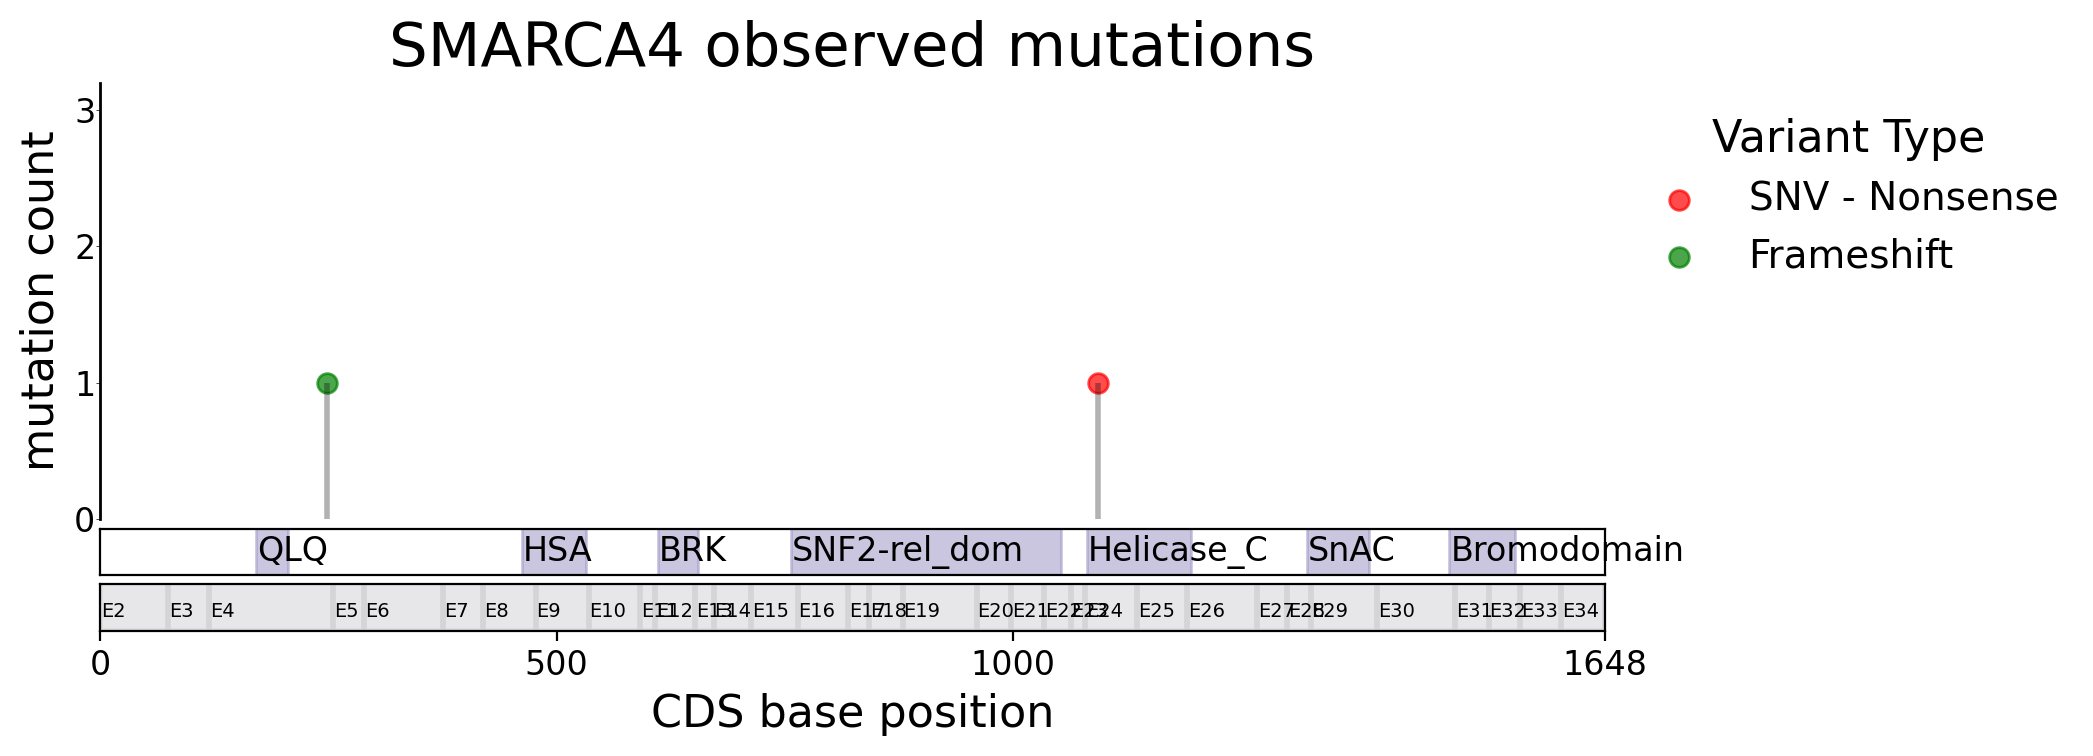

In [30]:
data = grp_snv_indels_df[['gene','Protein_position','number_observed_muts','Variant_type']].copy()

needle_plot(data, 'SMARCA4', 'ENST00000344626',color_dict,ylim_max=3.2)
plt.savefig('plots/needle_plot_smarca4.svg', bbox_inches='tight',format='svg')
plt.show()

# PADYZI needle plot

In [31]:
snv_indels_df = merged_df[['PATIENT','SYMBOL','mut','aa_change','Consequence','variant_type','SMARCB1 status','allele1','allele2']][(~merged_df['mut'].isnull())&(merged_df['SYMBOL']!='SMARCA4')].drop_duplicates()
print(len(snv_indels_df))
snv_indels_df['Protein_position'] = snv_indels_df['aa_change'].apply(lambda x: re.findall(r'\d+',x))
snv_indels_df['Protein_position'] = snv_indels_df['Protein_position'].apply(lambda x: x[0] if x != [] else '-')

snv_indels_df = snv_indels_df[snv_indels_df['PATIENT']=='PADYZI']

grp_snv_indels_df = snv_indels_df[['SYMBOL','Protein_position','Consequence','mut']].groupby(['SYMBOL','Protein_position','Consequence'],as_index=False).count()

def variant_type (x):
    if ',' in x:
        x = x.split(',')[0]
    if 'splice' in x:
        y = 'Splice variant'
    elif 'frameshift' in x:
        y = 'Frameshift'
    elif x == 'stop_gained':
        y = 'SNV - Nonsense'
    else:
        y = 'other'
    return y

grp_snv_indels_df['Variant_type'] = grp_snv_indels_df['Consequence'].apply(lambda x: variant_type(x))
grp_snv_indels_df = grp_snv_indels_df.rename(columns={'mut':'number_observed_muts','SYMBOL':'gene'})
grp_snv_indels_df

38


,gene,Protein_position,Consequence,number_observed_muts,Variant_type
0,SMARCB1,10,frameshift_variant,1,Frameshift
1,SMARCB1,206,stop_gained,1,SNV - Nonsense


/tmp/ipykernel_216211/3673731263.py:53: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_start_pos = math.ceil(cds_start/3)
/tmp/ipykernel_216211/3673731263.py:54: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  next_end_pos = math.ceil(cds_end/3)


{1: {'START': 0, 'END': 31, 'SIZE': 31, 'POS': 15}, 2: {'START': 31, 'END': 78, 'SIZE': 47, 'POS': 54}, 3: {'START': 78, 'END': 122, 'SIZE': 44, 'POS': 100}, 4: {'START': 122, 'END': 169, 'SIZE': 47, 'POS': 145}, 5: {'START': 169, 'END': 213, 'SIZE': 44, 'POS': 191}, 6: {'START': 213, 'END': 269, 'SIZE': 56, 'POS': 241}, 7: {'START': 269, 'END': 333, 'SIZE': 64, 'POS': 301}, 8: {'START': 333, 'END': 378, 'SIZE': 45, 'POS': 355}, 9: {'START': 378, 'END': 392, 'SIZE': 14, 'POS': 385}}


/tmp/ipykernel_216211/3673731263.py:101: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  max_aa = int(cds_gene['CDS Length']/3)
/tmp/ipykernel_216211/3673731263.py:171: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(xy=(start_base, 0), width=size_base, height=5, color=r["Color"], alpha=0.5, zorder=2,edgecolor="red",linewidth=2,fill=True,linestyle='solid')


386


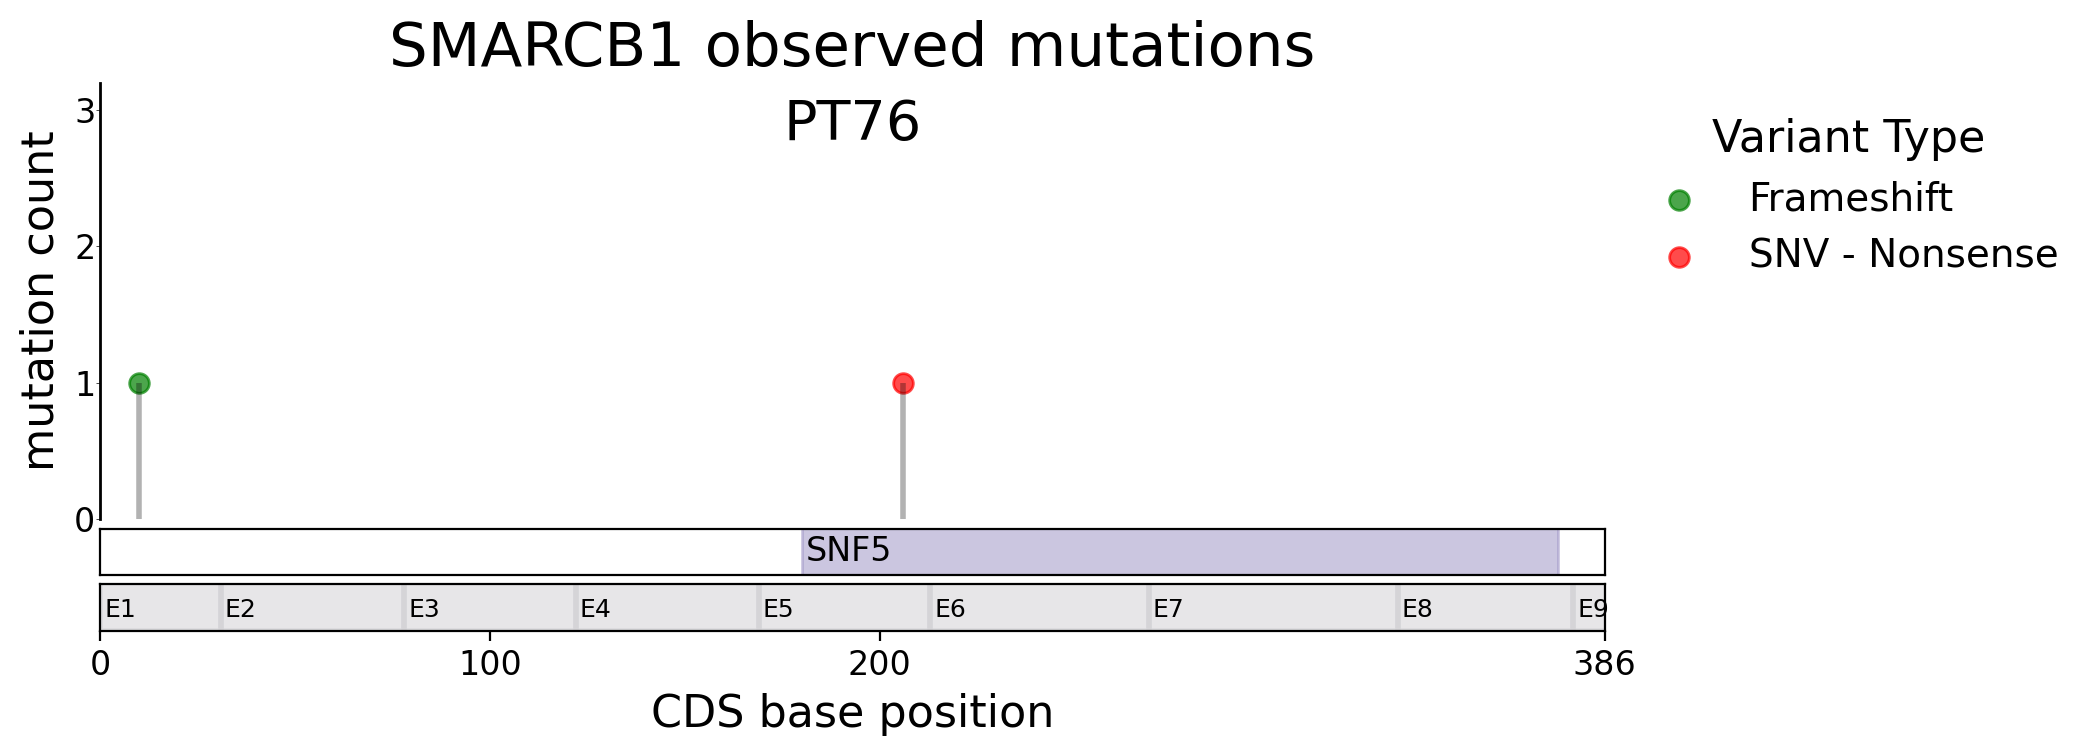

In [32]:
data = grp_snv_indels_df[['gene','Protein_position','number_observed_muts','Variant_type']].copy()

needle_plot(data, 'SMARCB1', 'ENST00000644036',color_dict,ylim_max=3.2)
pt_final = samples_final_ids_dict['PADYZI']
plt.title(pt_final,pad=160,size=20)
plt.savefig('plots/needle_plot_PT76_2germline.svg', bbox_inches='tight',format='svg')
plt.show()